<a href="https://colab.research.google.com/github/Priyanshiix12/MLE/blob/main/Credit_Card_Fraud_Detection_XGBoost_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection
### XGBoost + SMOTE + Decision Threshold Tuning + Feature Importance

**Case Study Goal:** Detect fraudulent credit-card transactions in a highly imbalanced dataset.

This notebook follows a clean ML workflow:
1. Load and understand the data
2. Analyze class imbalance
3. Split data into training and testing sets
4. Apply SMOTE to training data only
5. Train XGBoost
6. Evaluate using fraud-focused metrics
7. Tune the decision threshold
8. Interpret the model using feature importance

## 1. Install Required Libraries

Run this cell once in Google Colab.

In [1]:
!pip -q install xgboost imbalanced-learn

## 2. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 3. Load the Dataset

**Colab:** Click the folder icon → Upload → select `creditcard.csv`.

The file should be in `/content/creditcard.csv`.

### Mount Google Drive

Run this cell to mount your Google Drive. This will allow the notebook to access files stored in your Drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Assuming creditcard.csv is in the root of your Google Drive
FILE_PATH = '/content/drive/MyDrive/creditcard.csv'

Mounted at /content/drive


In [8]:


df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape}')

Dataset shape: (284807, 31)


In [5]:
df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Basic Dataset Inspection

In [10]:
display(df.head())

print('\nData types and non-null values:')
df.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 

In [9]:
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

display(df.describe().T)

Missing values: 0
Duplicate rows: 1081


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [11]:
display(df.head())

print('\nData types and non-null values:')
df.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 

In [12]:
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

display(df.describe().T)

Missing values: 0
Duplicate rows: 1081


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 5. Analyze the Target Variable

`Class = 0` represents a legitimate transaction and `Class = 1` represents fraud.

In [13]:
class_counts = df['Class'].value_counts().sort_index()
class_percentages = df['Class'].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages.round(4)
})

display(class_summary)

,Count,Percentage
Class,,
0,284315,99.8273
1,492,0.1727


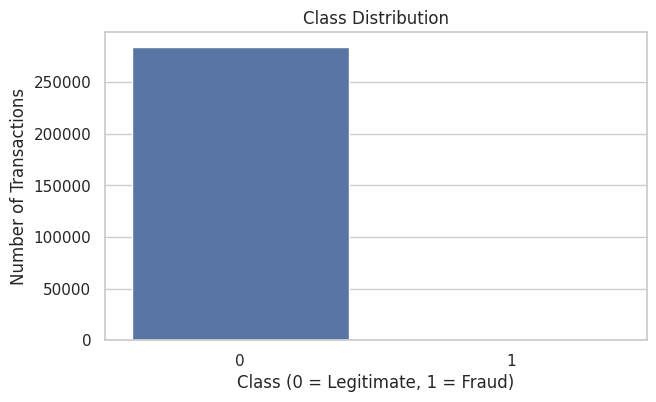

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()

### Why accuracy alone is not enough

Fraud is a very small minority class. A model that predicts almost every transaction as legitimate can achieve very high accuracy while missing most fraud. Therefore, we will focus on **precision, recall, F1-score, ROC-AUC, and especially PR-AUC**.

## 6. Separate Features and Target

In [15]:
X = df.drop(columns='Class')
y = df['Class']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')

Features: (284807, 30)
Target:   (284807,)


## 7. Train-Test Split

We split the data **before SMOTE**. The test set must keep the original real-world class distribution.

`stratify=y` ensures that both training and testing sets contain approximately the same proportion of fraud cases.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training set:', X_train.shape)
print('Testing set: ', X_test.shape)

print('\nTraining class distribution:')
print(y_train.value_counts())

print('\nTesting class distribution:')
print(y_test.value_counts())

Training set: (227845, 30)
Testing set:  (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 8. Handle Class Imbalance with SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** creates synthetic examples of the minority class instead of simply duplicating existing rows.

We apply it **only to the training data**. We do not modify the test set.

In [17]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print('Before SMOTE:')
print(y_train.value_counts())

print('\nAfter SMOTE:')
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


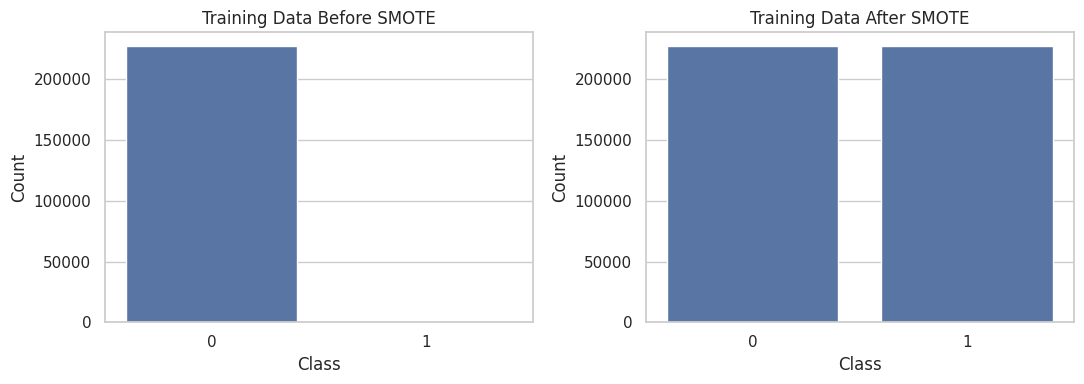

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Training Data Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title('Training Data After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 9. Train the XGBoost Model

XGBoost is a gradient-boosted decision-tree algorithm. Multiple trees are built sequentially, with later trees learning from errors made by earlier trees.

In [20]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)

print('XGBoost training completed.')

XGBoost training completed.


## 10. Generate Fraud Probabilities

Instead of immediately producing 0/1 predictions, we first obtain the model's estimated probability of fraud. This allows us to tune the decision threshold later.

In [21]:
y_probability = model.predict_proba(X_test)[:, 1]

print('First 10 fraud probabilities:')
print(np.round(y_probability[:10], 4))

First 10 fraud probabilities:
[0.0001 0.     0.0001 0.     0.001  0.0002 0.0001 0.0001 0.0001 0.0001]


## 11. Baseline Evaluation at Threshold = 0.50

The conventional classification threshold is 0.50:

- Probability ≥ 0.50 → Fraud
- Probability < 0.50 → Legitimate

In [ ]:
baseline_threshold = 0.50
y_pred = (y_probability >= baseline_threshold).astype(int)

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'], zero_division=0))

In [ ]:
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_probability),
    'PR-AUC': average_precision_score(y_test, y_probability)
}

display(pd.Series(baseline_metrics).to_frame('Score'))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Confusion Matrix — Threshold 0.50')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 12. Decision Threshold Tuning

A lower threshold makes the model more sensitive to fraud. This can increase recall, but it can also increase false positives.

We will compare several thresholds and select the one with the highest F1-score as a balanced baseline. In a real banking system, the final threshold should also consider the business cost of false positives and false negatives.

In [ ]:
thresholds = np.arange(0.10, 0.56, 0.05)
threshold_results = []

for threshold in thresholds:
    predictions = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        'Threshold': round(float(threshold), 2),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1 Score': f1_score(y_test, predictions, zero_division=0),
        'False Positives': fp,
        'False Negatives': fn
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results.round(4))

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(threshold_results['Threshold'], threshold_results['Precision'], marker='o', label='Precision')
plt.plot(threshold_results['Threshold'], threshold_results['Recall'], marker='o', label='Recall')
plt.plot(threshold_results['Threshold'], threshold_results['F1 Score'], marker='o', label='F1 Score')

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Decision Threshold')
plt.legend()
plt.show()

In [ ]:
best_row = threshold_results.loc[threshold_results['F1 Score'].idxmax()]
best_threshold = float(best_row['Threshold'])

print(f'Best threshold by F1-score: {best_threshold:.2f}')
display(best_row.to_frame('Value'))

## 13. Evaluate the Final Threshold

Now we use the selected threshold instead of automatically assuming 0.50.

In [ ]:
final_predictions = (y_probability >= best_threshold).astype(int)

print(f'Final threshold: {best_threshold:.2f}\n')
print(classification_report(
    y_test,
    final_predictions,
    target_names=['Legitimate', 'Fraud'],
    zero_division=0
))

In [ ]:
final_cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title(f'Final Confusion Matrix — Threshold {best_threshold:.2f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 14. Precision-Recall Curve

For highly imbalanced fraud detection, the Precision-Recall curve is especially informative because it focuses on performance for the positive/fraud class.

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
plt.show()

## 15. Feature Importance

XGBoost provides feature importance scores indicating how useful each feature was to the trained model. These scores show predictive importance, not causation.

In [22]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame('Importance'))

,Importance
V14,0.591847
V10,0.098339
V4,0.056441
V12,0.029841
V17,0.022831
V8,0.017497
V3,0.014434
V1,0.013403
V13,0.012595
V9,0.010233


In [ ]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind='barh')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 XGBoost Feature Importance Scores')
plt.show()

## 16. Final Model Summary

The model was trained on SMOTE-balanced training data and evaluated on the original, imbalanced test set. The final decision threshold was selected using F1-score.

### Key points to report
- The dataset is severely imbalanced, so accuracy alone is misleading.
- SMOTE was applied only to the training set to avoid test-set contamination.
- XGBoost was used as the fraud classification model.
- Fraud probabilities were used for decision-threshold tuning.
- Precision and recall trade off against each other as the threshold changes.
- PR-AUC is particularly useful for this highly imbalanced problem.
- Feature importance identifies the variables most useful to the XGBoost model.

**Important:** The numerical results in this notebook are produced from your actual run and should be used in the final report/presentation.